In [1]:
import pandas, numpy, sklearn, matplotlib, seaborn, joblib
print("All libraries OK")

All libraries OK


In [2]:
!python -m pip install scikit-learn pandas numpy matplotlib seaborn joblib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)

In [4]:
df = pd.read_csv("adult_processed.csv")
print(df.shape)
df.head()

(32058, 83)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,1.360450,1.712817,-0.41443,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,-1.356863,-0.310543,-0.02313,-0.232725,5.989283,-2.567806,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.402131,0.935970,-0.41443,-0.232725,5.989283,3.745241,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,-0.622454,0.637500,-0.02313,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.111955,0.928000,1.15077,-0.232725,5.989283,0.674029,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print(df.isnull().sum().sum())
print(df['income'].value_counts())

0
income
0    24532
1     7526
Name: count, dtype: int64


In [6]:
X = df.drop('income', axis=1)
y = df['income']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(25646, 82) (6412, 82)


In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

Accuracy: 0.852776044915783
ROC-AUC : 0.9050951011064944
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4907
           1       0.73      0.60      0.66      1505

    accuracy                           0.85      6412
   macro avg       0.80      0.77      0.78      6412
weighted avg       0.85      0.85      0.85      6412



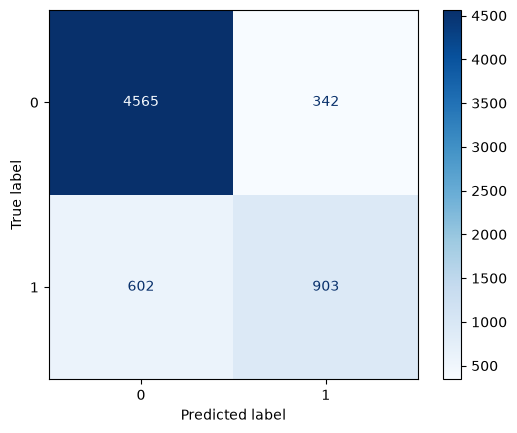

In [9]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.show()

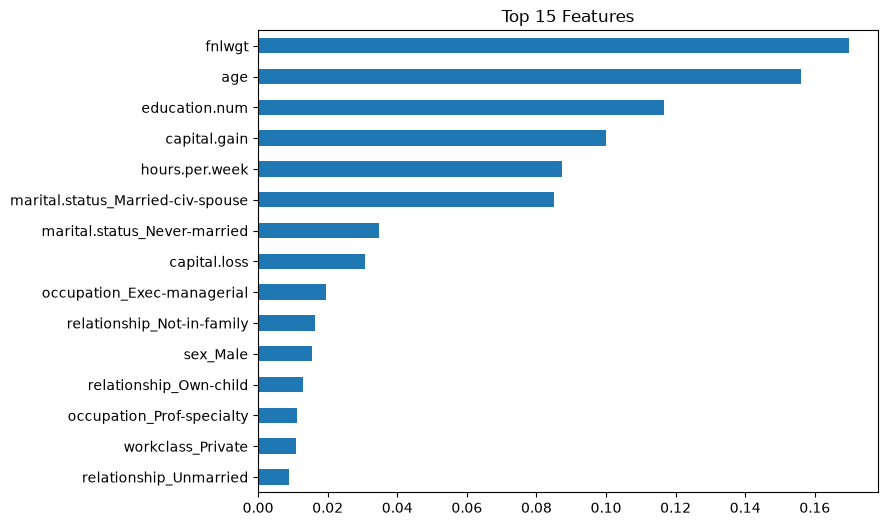

In [10]:
imp = pd.Series(rf.feature_importances_, index=X.columns).nlargest(15)
imp.sort_values().plot(kind='barh', figsize=(8,6), title="Top 15 Features")
plt.show()

In [11]:
scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(scores, scores.mean())

[0.78867748 0.83140986 0.82485964 0.83497114 0.82732803] 0.8214492295437708


In [17]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist, n_iter=20, cv=3, scoring='f1', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
print(search.best_params_)
best_rf = search.best_estimator_
print(classification_report(y_test, best_rf.predict(X_test)))

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced'}
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      4907
           1       0.59      0.84      0.69      1505

    accuracy                           0.82      6412
   macro avg       0.76      0.83      0.78      6412
weighted avg       0.86      0.82      0.83      6412



In [18]:
joblib.dump(rf, "rf_income_model.pkl")
print("Saved!")

Saved!


In [20]:
model = joblib.load("rf_income_model.pkl")
print(model.predict(X_test.iloc[:5]))

[0 0 0 0 0]
